In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time as tm
from sklearn.model_selection import train_test_split
from collections import Counter
import heapq
%matplotlib inline

C:\Users\turkm\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\turkm\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [3]:
zoo = pd.read_csv("GalaxyZoo1_DR_table2.csv")

In [4]:
zoo_clean = zoo[zoo["UNCERTAIN"]==0]

In [5]:
zoo_clean.drop(columns=["UNCERTAIN"], inplace = True)

C:\Users\turkm\AppData\Local\Temp/ipykernel_36500/694414332.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zoo_clean.drop(columns=["UNCERTAIN"], inplace = True)


In [6]:
zoo_clean

,OBJID,RA,DEC,NVOTE,P_EL,P_CW,P_ACW,P_EDGE,P_DK,P_MG,P_CS,P_EL_DEBIASED,P_CS_DEBIASED,SPIRAL,ELLIPTICAL
1,587727227300741210,00:00:00.74,-09:13:20.2,18,0.611,0.000,0.167,0.222,0.000,0.000,0.389,0.203,0.797,1,0
3,587730774962536596,00:00:01.38,+15:30:35.3,52,0.885,0.019,0.000,0.058,0.019,0.019,0.077,0.885,0.077,0,1
7,587727223024189605,00:00:02.00,+15:41:49.8,26,0.423,0.000,0.000,0.577,0.000,0.000,0.577,0.143,0.857,1,0
9,587727221950382424,00:00:02.41,+14:49:19.0,31,0.484,0.129,0.065,0.258,0.065,0.000,0.452,0.109,0.789,1,0
13,587727178449485858,00:00:03.33,-10:43:16.0,24,0.125,0.000,0.000,0.875,0.000,0.000,0.875,0.024,0.976,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667934,587727225153257594,23:59:57.69,-10:54:41.5,27,0.111,0.000,0.037,0.852,0.000,0.000,0.889,0.100,0.900,1,0
667937,587727227837612104,23:59:58.53,-08:43:19.6,48,0.083,0.021,0.688,0.167,0.021,0.021,0.875,0.029,0.928,1,0
667938,587730774962536585,23:59:58.71,+15:22:40.8,28,0.679,0.071,0.000,0.214,0.036,0.000,0.286,0.225,0.705,1,0
667939,587727226763870322,23:59:58.76,-09:41:34.7,35,0.171,0.800,0.000,0.029,0.000,0.000,0.829,0.057,0.943,1,0


In [7]:
zoo_clean[zoo_clean["ELLIPTICAL"]==0]

,OBJID,RA,DEC,NVOTE,P_EL,P_CW,P_ACW,P_EDGE,P_DK,P_MG,P_CS,P_EL_DEBIASED,P_CS_DEBIASED,SPIRAL,ELLIPTICAL
1,587727227300741210,00:00:00.74,-09:13:20.2,18,0.611,0.000,0.167,0.222,0.000,0.000,0.389,0.203,0.797,1,0
7,587727223024189605,00:00:02.00,+15:41:49.8,26,0.423,0.000,0.000,0.577,0.000,0.000,0.577,0.143,0.857,1,0
9,587727221950382424,00:00:02.41,+14:49:19.0,31,0.484,0.129,0.065,0.258,0.065,0.000,0.452,0.109,0.789,1,0
13,587727178449485858,00:00:03.33,-10:43:16.0,24,0.125,0.000,0.000,0.875,0.000,0.000,0.875,0.024,0.976,1,0
18,587727180596969574,00:00:04.60,-08:56:37.6,30,0.167,0.333,0.033,0.467,0.000,0.000,0.833,0.075,0.925,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667934,587727225153257594,23:59:57.69,-10:54:41.5,27,0.111,0.000,0.037,0.852,0.000,0.000,0.889,0.100,0.900,1,0
667937,587727227837612104,23:59:58.53,-08:43:19.6,48,0.083,0.021,0.688,0.167,0.021,0.021,0.875,0.029,0.928,1,0
667938,587730774962536585,23:59:58.71,+15:22:40.8,28,0.679,0.071,0.000,0.214,0.036,0.000,0.286,0.225,0.705,1,0
667939,587727226763870322,23:59:58.76,-09:41:34.7,35,0.171,0.800,0.000,0.029,0.000,0.000,0.829,0.057,0.943,1,0


In [8]:
elliptical_zero = zoo_clean[zoo_clean["ELLIPTICAL"] == 0]

In [9]:
rows_to_drop = elliptical_zero.sample(n=120000, random_state=42).index

In [10]:
zoo_clean = zoo_clean.drop(index=rows_to_drop).reset_index(drop=True)
print(zoo_clean["ELLIPTICAL"].value_counts())

ELLIPTICAL
0    70225
1    62190
Name: count, dtype: int64


In [11]:
OBJID = np.array(zoo_clean["OBJID"])

In [12]:
zoo_clean.drop(columns=["OBJID", "RA", "DEC"], inplace=True) #drops the columns related to the location of the galaxies and ids not important for prediction from my physics knowledge. just a identification of this specific galaxy.

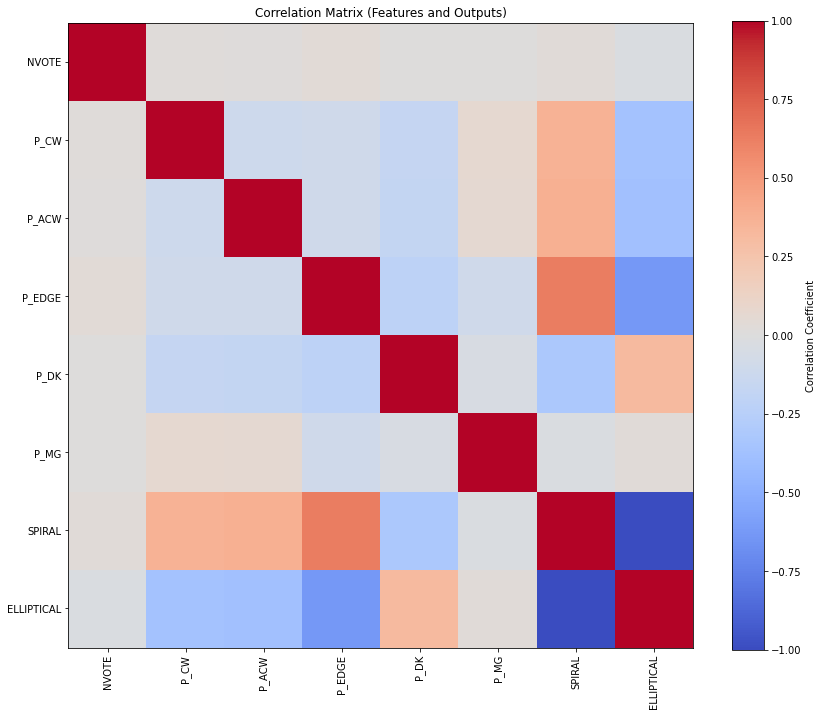

In [13]:
feature_columns = ['NVOTE', 'P_CW', 'P_ACW', 'P_EDGE', 'P_DK', 'P_MG']
output_columns = ['SPIRAL', 'ELLIPTICAL']

data_array = zoo_clean[feature_columns + output_columns].to_numpy()
columns = feature_columns + output_columns


def correlation_coefficient(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean) ** 2)) * np.sqrt(np.sum((y - y_mean) ** 2))
    return numerator / denominator if denominator != 0 else 0

n_features = len(columns)
corr_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        corr_matrix[i, j] = correlation_coefficient(data_array[:, i], data_array[:, j])

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label="Correlation Coefficient")
plt.title("Correlation Matrix (Features and Outputs)")
plt.xticks(range(n_features), columns, rotation=90)
plt.yticks(range(n_features), columns)
plt.tight_layout()
plt.show()


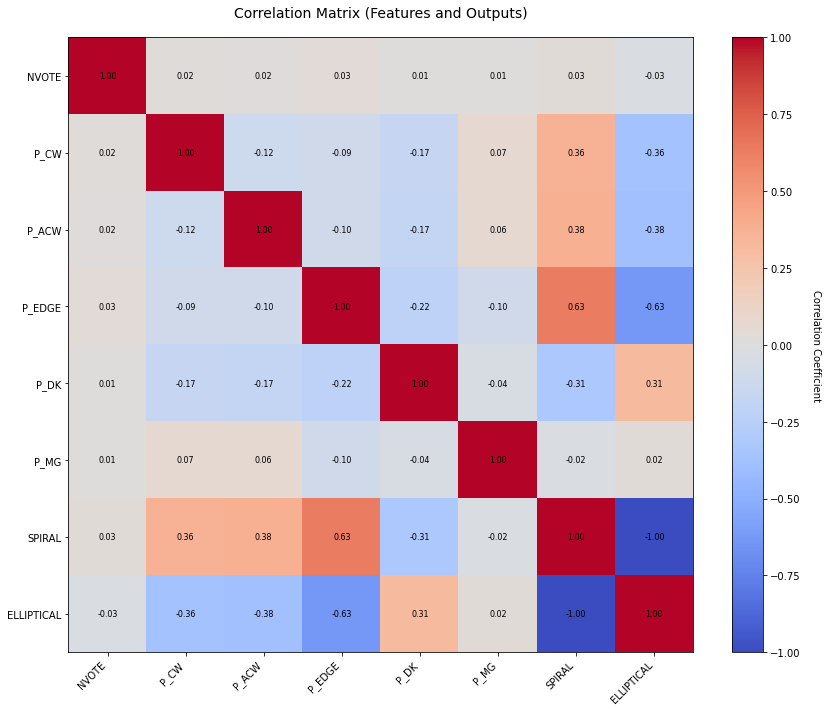

In [14]:

n_features = 6 + 2  
columns = ['NVOTE', 'P_CW', 'P_ACW', 'P_EDGE', 'P_DK', 'P_MG', 'SPIRAL', 'ELLIPTICAL']


plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')

cbar = plt.colorbar()
cbar.set_label("Correlation Coefficient", rotation=270, labelpad=20)


plt.grid(False)

plt.title("Correlation Matrix (Features and Outputs)", fontsize=14, pad=20)
plt.xticks(range(n_features), columns, rotation=45, ha="right", fontsize=10)
plt.yticks(range(n_features), columns, fontsize=10)

for i in range(n_features):
    for j in range(n_features):
        value = corr_matrix[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

In [15]:
corr_matrix_df = pd.DataFrame(corr_matrix, index=columns, columns=columns)

In [16]:
corr_matrix_df

,NVOTE,P_CW,P_ACW,P_EDGE,P_DK,P_MG,SPIRAL,ELLIPTICAL
NVOTE,1.000000,0.017893,0.015509,0.034111,0.007773,0.006602,0.027301,-0.027301
P_CW,0.017893,1.000000,-0.115005,-0.094080,-0.166024,0.069527,0.361728,-0.361728
P_ACW,0.015509,-0.115005,1.000000,-0.096158,-0.174216,0.057499,0.377062,-0.377062
P_EDGE,0.034111,-0.094080,-0.096158,1.000000,-0.215527,-0.100507,0.626116,-0.626116
P_DK,0.007773,-0.166024,-0.174216,-0.215527,1.000000,-0.039116,-0.312895,0.312895
P_MG,0.006602,0.069527,0.057499,-0.100507,-0.039116,1.000000,-0.024592,0.024592
SPIRAL,0.027301,0.361728,0.377062,0.626116,-0.312895,-0.024592,1.000000,-1.000000
ELLIPTICAL,-0.027301,-0.361728,-0.377062,-0.626116,0.312895,0.024592,-1.000000,1.000000


In [17]:
reduced_corr_matrix_df = corr_matrix_df.drop(index=feature_columns, columns=output_columns)

In [18]:
reduced_corr_matrix_df

,NVOTE,P_CW,P_ACW,P_EDGE,P_DK,P_MG
SPIRAL,0.027301,0.361728,0.377062,0.626116,-0.312895,-0.024592
ELLIPTICAL,-0.027301,-0.361728,-0.377062,-0.626116,0.312895,0.024592


In [19]:
features_array = zoo_clean[feature_columns].to_numpy()
outputs_array = zoo_clean["ELLIPTICAL"].to_numpy() #Take only the ELLIPTICAL, if it is 0 it is SPIRAL if it is 1 it is ELLIPTICAL

In [20]:
features_array, outputs_array

(array([[5.20e+01, 1.90e-02, 0.00e+00, 5.80e-02, 1.90e-02, 1.90e-02],
        [2.60e+01, 0.00e+00, 0.00e+00, 5.77e-01, 0.00e+00, 0.00e+00],
        [3.10e+01, 1.29e-01, 6.50e-02, 2.58e-01, 6.50e-02, 0.00e+00],
        ...,
        [4.00e+01, 9.75e-01, 0.00e+00, 2.50e-02, 0.00e+00, 0.00e+00],
        [5.60e+01, 9.29e-01, 0.00e+00, 1.80e-02, 1.80e-02, 1.80e-02],
        [2.70e+01, 0.00e+00, 3.70e-02, 8.52e-01, 0.00e+00, 0.00e+00]]),
 array([1, 0, 0, ..., 0, 0, 0], dtype=int64))

In [21]:

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]        
        k_indices = np.argsort(distances)[:self.k]             
        k_nearest_labels = [self.y_train[i] for i in k_indices]           
        most_common = Counter(k_nearest_labels).most_common(1)  
        return most_common[0][0]
    


In [22]:
class KNNClassifier_Pq:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        max_heap = []
        
        for idx, x_train in enumerate(self.X_train):
            distance = np.linalg.norm(x - x_train)
            
            if len(max_heap) < self.k:
                heapq.heappush(max_heap, (-distance, idx))
            else:
                heapq.heappushpop(max_heap, (-distance, idx))
        
       
        k_indices = [idx for _, idx in max_heap]             
        k_nearest_labels = [self.y_train[i] for i in k_indices]        
        most_common = Counter(k_nearest_labels).most_common(1)
        
        return most_common[0][0]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    features_array[:20000], outputs_array[:20000], test_size=0.2, random_state=42
)

In [29]:
y_train = y_train.ravel()  
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (16000, 6)
y_train shape: (16000,)


In [30]:
X_train_new = X_train[:]
y_train_new = y_train[:]
X_test_new = X_test[:]
y_test_new = y_test[:]

In [32]:
start_time = tm.time()
knn = KNNClassifier_Pq(k=1)
knn.fit(X_train_new, y_train_new)
predictions = knn.predict(X_test_new)
end_time = tm.time()
elapsed_time = end_time - start_time
print(f"Elapsed time for k-NN execution: {elapsed_time:.4f} seconds")

accuracy = np.mean(predictions == y_test_new)
print(f"Accuracy: {accuracy * 100:.2f}%")

    

Elapsed time for k-NN execution: 176.8351 seconds
Accuracy: 98.20%


In [33]:
def compute_confusion_matrix(y_true, y_pred):
   
    class_labels = np.unique(np.concatenate((y_true, y_pred)))
    n_classes = len(class_labels)  
    conf_matrix = np.zeros((n_classes, n_classes), dtype=int)    
    label_to_index = {label: index for index, label in enumerate(class_labels)}
    
    for true_label, pred_label in zip(y_true, y_pred):
        i = label_to_index[true_label]
        j = label_to_index[pred_label]
        conf_matrix[i][j] += 1
    
    return conf_matrix, class_labels


In [34]:
conf_matrix, class_labels = compute_confusion_matrix(y_test_new, predictions)
print("Confusion Matrix:")
print(conf_matrix)
print("Class Labels:", class_labels)

Confusion Matrix:
[[2021   38]
 [  34 1907]]
Class Labels: [0 1]


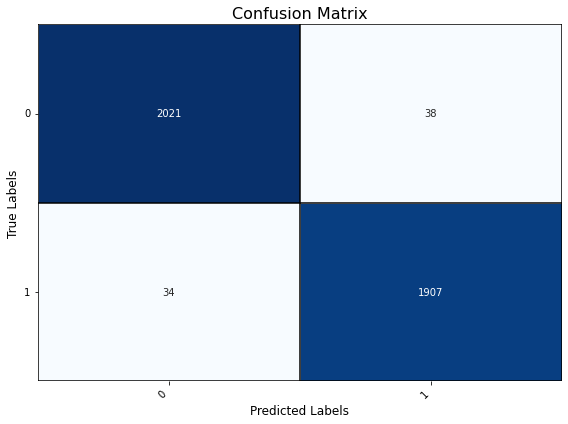

In [38]:
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_labels, columns=class_labels)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=False)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45, ha="right", fontsize=10)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0, fontsize=10)

ax.hlines(np.arange(len(class_labels) + 1), *ax.get_xlim(), colors="black", linewidth=1.5)
ax.vlines(np.arange(len(class_labels) + 1), *ax.get_ylim(), colors="black", linewidth=1.5)

plt.tight_layout()
plt.show()

In [39]:
def compute_precision_recall_f1(conf_matrix):
    
    n_classes = conf_matrix.shape[0]    
    precision_dict = {}
    recall_dict = {}
    f1_dict = {}
    
    for i in range(n_classes):
        TP = conf_matrix[i, i]
        FP = conf_matrix[:, i].sum() - TP
        FN = conf_matrix[i, :].sum() - TP
        
        # Precision: TP / (TP + FP)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        # Recall: TP / (TP + FN)
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        # F1-Score: 2 * (Precision * Recall) / (Precision + Recall)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        precision_dict[i] = precision
        recall_dict[i] = recall
        f1_dict[i] = f1
    
    return precision_dict, recall_dict, f1_dict

""" precision_dict, recall_dict, f1_dict = compute_precision_recall_f1(conf_matrix)
precision_scores = {class_labels[i]: precision_dict[i] for i in range(len(class_labels))}
recall_scores = {class_labels[i]: recall_dict[i] for i in range(len(class_labels))}
f1_scores = {class_labels[i]: f1_dict[i] for i in range(len(class_labels))}

print("Precision per class:", precision_scores)
print("Recall per class:", recall_scores)
print("F1-Score per class:", f1_scores) """


' precision_dict, recall_dict, f1_dict = compute_precision_recall_f1(conf_matrix)\nprecision_scores = {class_labels[i]: precision_dict[i] for i in range(len(class_labels))}\nrecall_scores = {class_labels[i]: recall_dict[i] for i in range(len(class_labels))}\nf1_scores = {class_labels[i]: f1_dict[i] for i in range(len(class_labels))}\n\nprint("Precision per class:", precision_scores)\nprint("Recall per class:", recall_scores)\nprint("F1-Score per class:", f1_scores) '

In [40]:
def k_fold_cross_validation_knn(model_class, X, y, k=5, num_k=3):
       
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]
  
    fold_size = len(X) // k
    scores = []
    
    for fold in range(k):
        
        start = fold * fold_size
        end = start + fold_size
        X_val = X[start:end]
        y_val = y[start:end]
        X_train = np.concatenate((X[:start], X[end:]), axis=0)
        y_train = np.concatenate((y[:start], y[end:]), axis=0)
     
        model = model_class(num_k)  
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        accuracy = np.mean(predictions == y_val)
        scores.append(accuracy)

    return scores

In [41]:
k_scores = []
for i in range(1,11):
    scores = k_fold_cross_validation_knn(KNNClassifier_Pq, features_array[:5000], outputs_array[:5000], k=5, num_k=i)
    print("Num_k:", i)
    print("Accuracy scores for each fold:", scores)
    print("Mean accuracy:", np.mean(scores))
    k_scores.append(np.mean(scores))

Num_k: 1
Accuracy scores for each fold: [0.978, 0.986, 0.979, 0.978, 0.973]
Mean accuracy: 0.9788
Num_k: 2
Accuracy scores for each fold: [0.968, 0.965, 0.968, 0.975, 0.968]
Mean accuracy: 0.9687999999999999
Num_k: 3
Accuracy scores for each fold: [0.98, 0.963, 0.969, 0.983, 0.97]
Mean accuracy: 0.9730000000000001
Num_k: 4
Accuracy scores for each fold: [0.969, 0.964, 0.954, 0.963, 0.973]
Mean accuracy: 0.9645999999999999
Num_k: 5
Accuracy scores for each fold: [0.969, 0.965, 0.965, 0.966, 0.972]
Mean accuracy: 0.9673999999999999
Num_k: 6
Accuracy scores for each fold: [0.96, 0.955, 0.953, 0.957, 0.96]
Mean accuracy: 0.9570000000000001
Num_k: 7
Accuracy scores for each fold: [0.948, 0.957, 0.963, 0.961, 0.955]
Mean accuracy: 0.9568
Num_k: 8
Accuracy scores for each fold: [0.944, 0.955, 0.95, 0.937, 0.955]
Mean accuracy: 0.9482000000000002
Num_k: 9
Accuracy scores for each fold: [0.95, 0.948, 0.948, 0.952, 0.956]
Mean accuracy: 0.9507999999999999
Num_k: 10
Accuracy scores for each fold:

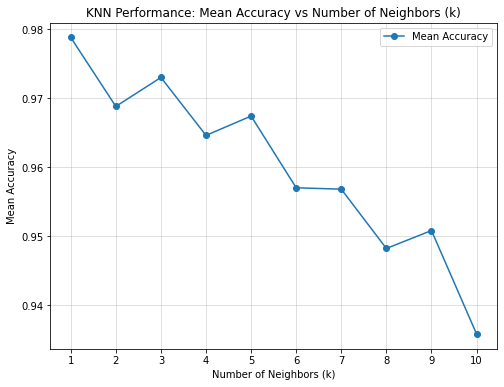

In [42]:
num_k_values = list(range(1, 11))  

plt.figure(figsize=(8, 6))
plt.plot(num_k_values, k_scores, marker='o', linestyle='-', label='Mean Accuracy')
plt.title("KNN Performance: Mean Accuracy vs Number of Neighbors (k)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Accuracy")
plt.xticks(num_k_values)  
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [40]:
precision_dict, recall_dict, f1_dict = compute_precision_recall_f1(conf_matrix)
precision_scores = {class_labels[i]: precision_dict[i] for i in range(len(class_labels))}
recall_scores = {class_labels[i]: recall_dict[i] for i in range(len(class_labels))}
f1_scores = {class_labels[i]: f1_dict[i] for i in range(len(class_labels))}

print("Precision per class:", precision_scores)
print("Recall per class:", recall_scores)
print("F1-Score per class:", f1_scores)

Precision per class: {0: 0.9834549878345499, 1: 0.9804627249357326}
Recall per class: {0: 0.9815444390480816, 1: 0.9824832560535807}
F1-Score per class: {0: 0.982498784637822, 1: 0.9814719505918682}


In [43]:

class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        '''Fit the decision tree to the data'''
        self.tree = self._build_tree(X, y, depth=0)

    def predict(self, X):
        '''Predict values for the given input data'''
        return np.array([self._predict_row(x, self.tree) for x in X])

    def _build_tree(self, X, y, depth):
        '''Recursive function to build the decision tree'''
        # Stopping criteria
        if (depth >= self.max_depth) or (len(y) < self.min_samples_split) or (len(np.unique(y)) == 1):
            return {'value': np.mean(y)}

        # Find the best split
        feature_idx, threshold = self._best_split(X, y)

        if feature_idx is None:
            return {'value': np.mean(y)}

        left_indices = X[:, feature_idx] <= threshold
        right_indices = X[:, feature_idx] > threshold

        # Recursively build left and right branches
        left_subtree = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        # Return the decision node
        return {
            'feature_idx': feature_idx,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def _best_split(self, X, y):
        '''Find the best split for a node'''
        best_feature, best_threshold = None, None
        best_mse = float('inf')
        n_samples, n_features = X.shape

        # Loop over all features
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])

            # Try each threshold as a split point
            for threshold in thresholds:
                left_indices = X[:, feature_idx] <= threshold
                right_indices = X[:, feature_idx] > threshold

                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                # Calculate the MSE for this split
                mse = self._calculate_mse(y[left_indices], y[right_indices])

                # Update the best split if this one is better
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def _calculate_mse(self, left_y, right_y):
        '''Calculate Mean Squared Error for a given split'''
        left_mse = np.var(left_y) * len(left_y) if len(left_y) > 0 else 0
        right_mse = np.var(right_y) * len(right_y) if len(right_y) > 0 else 0
        total_mse = (left_mse + right_mse) / (len(left_y) + len(right_y))
        return total_mse

    def _predict_row(self, x, tree):
        '''Predict a value for a single data point'''
        # If the node is a leaf node, return its value
        if 'value' in tree:
            return tree['value']

        # Otherwise, traverse the tree
        feature_idx = tree['feature_idx']
        threshold = tree['threshold']

        if x[feature_idx] <= threshold:
            return self._predict_row(x, tree['left'])
        else:
            return self._predict_row(x, tree['right'])

    def update_leaf_values(self, X, negative_gradients, hessians):
        '''Update the terminal nodes based on negative gradients and Hessians'''
        def _traverse_and_update(node, X, negative_gradients, hessians):
            if 'value' in node:  # If it's a leaf node
                indices = self._get_samples_in_leaf(node, X)
                if len(indices) > 0:
                    negative_gradients_in_leaf = negative_gradients[indices]
                    hessians_in_leaf = hessians[indices]
                    if np.sum(hessians_in_leaf) != 0:
                        node['value'] = np.sum(negative_gradients_in_leaf) / np.sum(hessians_in_leaf)
            else:
                # Recur for left and right branches
                feature_idx = node['feature_idx']
                threshold = node['threshold']
                left_indices = X[:, feature_idx] <= threshold
                right_indices = X[:, feature_idx] > threshold
                _traverse_and_update(node['left'], X[left_indices], negative_gradients[left_indices], hessians[left_indices])
                _traverse_and_update(node['right'], X[right_indices], negative_gradients[right_indices], hessians[right_indices])

        _traverse_and_update(self.tree, X, negative_gradients, hessians)

    def _get_samples_in_leaf(self, node, X):
        '''Find samples that belong to a specific leaf node'''
        indices = []
        for i, x in enumerate(X):
            current_node = self.tree  # Start from the root
            while 'value' not in current_node:  # Traverse until a leaf node is reached
                feature_idx = current_node['feature_idx']
                threshold = current_node['threshold']
                if x[feature_idx] <= threshold:
                    current_node = current_node['left']
                else:
                    current_node = current_node['right']
            if current_node is node:
                indices.append(i)
        return indices

In [44]:

class CustomGradientBoostingClassifier:
    
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y):
        """
        Fit the Gradient Boosting model to the provided training data.
        """
        self.num_classes = len(np.unique(y))
        y_encoded = self._one_hot_encode(y)

        initial_raw_predictions = np.zeros_like(y_encoded)
        class_probs = self._compute_softmax(initial_raw_predictions)

        self.models = []

        for i in range(self.n_estimators):
            trees_per_class = []

            for class_idx in range(self.num_classes):
                residuals = self._compute_residuals(y_encoded[:, class_idx], class_probs[:, class_idx])
                hessians = self._compute_hessian(class_probs[:, class_idx])

                weak_learner = DecisionTreeRegressorScratch(max_depth=self.max_depth, min_samples_split=2)
                weak_learner.fit(X, residuals)

                self._adjust_terminal_nodes(weak_learner, X, residuals, hessians)

                initial_raw_predictions[:, class_idx] += self.learning_rate * weak_learner.predict(X)

                trees_per_class.append(weak_learner)

            class_probs = self._compute_softmax(initial_raw_predictions)
            self.models.append(trees_per_class)

    def _one_hot_encode(self, y):
   
        if isinstance(y, pd.Series):
            y = y.values
        y = np.array(y)
    
        n_classes = np.max(y) + 1
    
        y_ohe = np.zeros((y.shape[0], n_classes))
      
        y_ohe[np.arange(y.shape[0]), y] = 1

        return y_ohe

    def _compute_residuals(self, y_true, class_prob):
        """Calculate residuals (negative gradients)."""
        return y_true - class_prob

    def _compute_hessian(self, class_prob):
        """Calculate the hessian, representing the second derivative of the loss function."""
        return class_prob * (1 - class_prob)

    def _compute_softmax(self, raw_preds):
        """Compute softmax transformation on raw predictions to obtain probabilities."""
        exp_vals = np.exp(raw_preds)
        exp_sum = np.sum(exp_vals, axis=1, keepdims=True)
        return exp_vals / exp_sum

    def _adjust_terminal_nodes(self, tree, X, residuals, hessians):
        """
        Adjust the values at terminal nodes of the decision tree based on residuals and hessians.

        """
        def _traverse_and_update(node, X, residuals, hessians):
            # Check if we are at a leaf node
            if 'value' in node:
                leaf_indices = self._get_indices_in_leaf(node, X)
                if len(leaf_indices) > 0:
                    residuals_leaf = residuals[leaf_indices]
                    hessians_leaf = hessians[leaf_indices]
                    if np.sum(hessians_leaf) != 0:
                        node['value'] = np.sum(residuals_leaf) / np.sum(hessians_leaf)
            else:
                # Recursively handle children (left and right branches)
                feature_idx = node['feature_idx']
                threshold = node['threshold']

                left_indices = X[:, feature_idx] <= threshold
                right_indices = X[:, feature_idx] > threshold

                _traverse_and_update(node['left'], X[left_indices], residuals[left_indices], hessians[left_indices])
                _traverse_and_update(node['right'], X[right_indices], residuals[right_indices], hessians[right_indices])

        # Start from the root node of the tree
        _traverse_and_update(tree.tree, X, residuals, hessians)

    def predict_proba(self, X):
        """
        Predict class probabilities for given input data.

        """
        initial_raw_predictions = np.zeros((X.shape[0], self.num_classes))

        for model_round in self.models:
            for class_idx, weak_learner in enumerate(model_round):
                initial_raw_predictions[:, class_idx] += self.learning_rate * weak_learner.predict(X)

        return self._compute_softmax(initial_raw_predictions)

    def predict(self, X):
        """
        Predict class labels for given input data.

        """
        class_probs = self.predict_proba(X)
        return np.argmax(class_probs, axis=1)

    def _get_indices_in_leaf(self, node, X):
        """Find indices of samples that belong to a given leaf node."""
        indices = []

        for i, x in enumerate(X):
            current_node = node
            while 'value' not in current_node:
                feature_idx = current_node['feature_idx']
                threshold = current_node['threshold']

                if x[feature_idx] <= threshold:
                    current_node = current_node['left']
                else:
                    current_node = current_node['right']

            if current_node is node:
                indices.append(i)

        return indices


In [68]:

Gradient_booster = CustomGradientBoostingClassifier(n_estimators=10, learning_rate=0.3, max_depth=6)
                                              
Gradient_booster.fit(X_train_new, y_train_new)


In [45]:

def k_fold_cross_validation_gbm(model_class, X, y, k=5, **model_params):
    
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]

    fold_size = len(X) // k
    scores = []

    for fold in range(k):
        start = fold * fold_size
        end = start + fold_size

        X_val = X[start:end]
        y_val = y[start:end]
        X_train = np.concatenate((X[:start], X[end:]), axis=0)
        y_train = np.concatenate((y[:start], y[end:]), axis=0)

        model = model_class(**model_params)
        
        model.fit(X_train, y_train)
        
        predictions = model.predict(X_val)
        
        accuracy = np.mean(predictions == y_val)
        scores.append(accuracy)

    return scores



In [51]:

n_estimators_list = [10, 50, 100]
learning_rate_list = [0.01, 0.1, 0.3]
max_depth_list = [3, 6, 9]

best_params = None
best_score = -np.inf

results = []

for n_estimators in n_estimators_list:
    for learning_rate in learning_rate_list:
        for max_depth in max_depth_list:
            model_params = {
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
                'max_depth': max_depth
            }
            
            cv_scores = k_fold_cross_validation_gbm(CustomGradientBoostingClassifier, X_train_new, y_train_new, k=5, **model_params)
            avg_cv_score = np.mean(cv_scores)
            
            results.append({
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
                'max_depth': max_depth,
                'cv_score': avg_cv_score
            })
            
            print(f"n_estimators: {n_estimators}, learning_rate: {learning_rate}, max_depth: {max_depth} => CV Score: {avg_cv_score:.4f}")

           
            if avg_cv_score > best_score:
                best_score = avg_cv_score
                best_params = model_params

print("\nBest Hyperparameters:")
print(f"n_estimators: {best_params['n_estimators']}, learning_rate: {best_params['learning_rate']}, max_depth: {best_params['max_depth']}")
print(f"Best Cross-Validation Score: {best_score:.4f}")


n_estimators: 10, learning_rate: 0.01, max_depth: 3 => CV Score: 0.9883
n_estimators: 10, learning_rate: 0.01, max_depth: 6 => CV Score: 0.9899
n_estimators: 10, learning_rate: 0.01, max_depth: 9 => CV Score: 0.9871
n_estimators: 10, learning_rate: 0.1, max_depth: 3 => CV Score: 0.9885
n_estimators: 10, learning_rate: 0.1, max_depth: 6 => CV Score: 0.9901
n_estimators: 10, learning_rate: 0.1, max_depth: 9 => CV Score: 0.9889
n_estimators: 10, learning_rate: 0.3, max_depth: 3 => CV Score: 0.9892
n_estimators: 10, learning_rate: 0.3, max_depth: 6 => CV Score: 0.9880
n_estimators: 10, learning_rate: 0.3, max_depth: 9 => CV Score: 0.9875


KeyboardInterrupt: 

In [46]:
start_time = tm.time()
Gradient_booster = CustomGradientBoostingClassifier(n_estimators=10, learning_rate=0.1, max_depth=6) #With best parameters found above                                           
Gradient_booster.fit(X_train_new, y_train_new)
predictions_gb = Gradient_booster.predict(X_test_new)
end_time = tm.time()
elapsed_time = end_time - start_time
conf_matrix_gb, class_labels_gb = compute_confusion_matrix(y_test_new, predictions_gb)
print(f"Elapsed time for GBM execution: {elapsed_time:.4f} seconds")


Elapsed time for k-NN execution: 35.6200 seconds


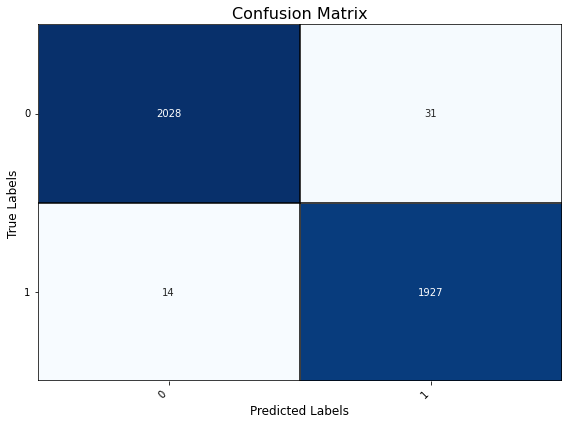

In [50]:
conf_matrix_df_gb = pd.DataFrame(conf_matrix_gb, index=class_labels_gb, columns=class_labels_gb)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(conf_matrix_df_gb, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=False)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.xticks(np.arange(len(class_labels_gb)) + 0.5, class_labels_gb, rotation=45, ha="right", fontsize=10)
plt.yticks(np.arange(len(class_labels_gb)) + 0.5, class_labels_gb, rotation=0, fontsize=10)

ax.hlines(np.arange(len(class_labels_gb) + 1), *ax.get_xlim(), colors="black", linewidth=1.5)
ax.vlines(np.arange(len(class_labels_gb) + 1), *ax.get_ylim(), colors="black", linewidth=1.5)

plt.tight_layout()
plt.show()

In [47]:
precision_dict, recall_dict, f1_dict = compute_precision_recall_f1(conf_matrix_gb)
precision_scores = {class_labels_gb[i]: precision_dict[i] for i in range(len(class_labels_gb))}
recall_scores = {class_labels_gb[i]: recall_dict[i] for i in range(len(class_labels_gb))}
f1_scores = {class_labels_gb[i]: f1_dict[i] for i in range(len(class_labels_gb))}

print("Precision per class for GB:", precision_scores)
print("Recall per class for GB:", recall_scores)
print("F1-Score per class for GB:", f1_scores)

Precision per class for GB: {0: 0.9931439764936337, 1: 0.984167517875383}
Recall per class for GB: {0: 0.9849441476444876, 1: 0.9927872230808862}
F1-Score per class for GB: {0: 0.9890270665691295, 1: 0.9884585791228521}


In [52]:
n_estimators_vals = [r['n_estimators'] for r in results]
learning_rate_vals = [r['learning_rate'] for r in results]
max_depth_vals = [r['max_depth'] for r in results]
cv_scores_vals = [r['cv_score'] for r in results]


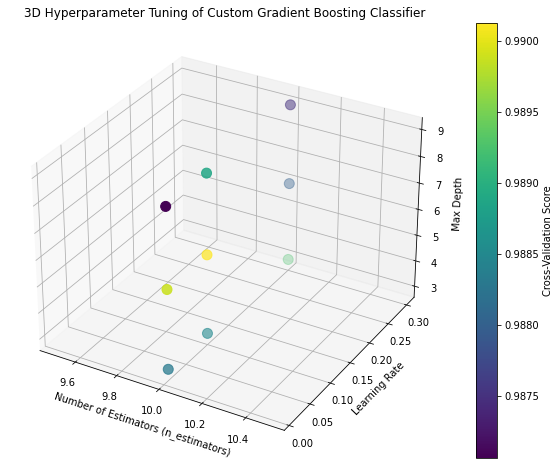

In [53]:

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(n_estimators_vals, learning_rate_vals, max_depth_vals, c=cv_scores_vals, cmap='viridis', s=100)

plt.colorbar(sc, label='Cross-Validation Score')

ax.set_xlabel('Number of Estimators (n_estimators)')
ax.set_ylabel('Learning Rate')
ax.set_zlabel('Max Depth')
ax.set_title('3D Hyperparameter Tuning of Custom Gradient Boosting Classifier')

plt.show()

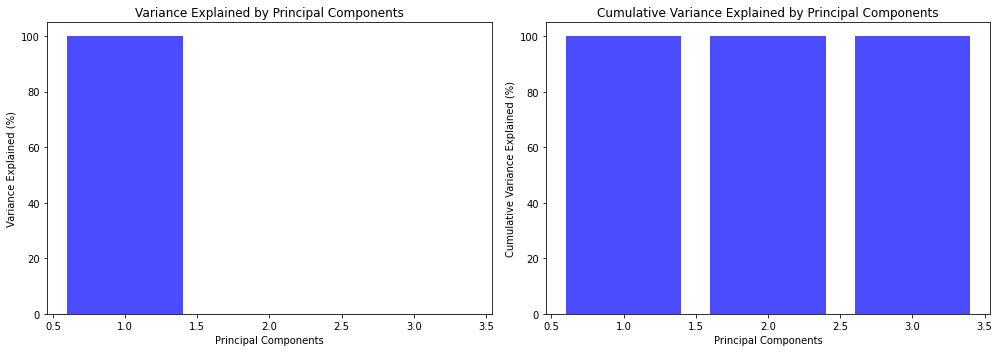

In [54]:

class PCAFromScratch:
    """
    Principal Component Analysis (PCA) implementation from scratch.

    Parameters
    ----------
    n_components : int
        Number of principal components to keep.
    """
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.explained_variances = None

    def fit(self, X):
        """
        Fit the PCA model to the data X.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            The input data to be reduced.
        """
        # Step 1: Mean-center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Step 2: Compute covariance matrix of the centered data
        covariance_matrix = np.cov(X_centered, rowvar=False)

        # Step 3: Compute eigenvalues and eigenvectors of the covariance matrix
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        # Step 4: Sort eigenvectors by descending eigenvalues (variance)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        sorted_eigenvalues = eigenvalues[sorted_indices]
        sorted_eigenvectors = eigenvectors[:, sorted_indices]

        # Step 5: Store the top n_components eigenvectors and eigenvalues
        self.components = sorted_eigenvectors[:, :self.n_components]  # Shape: (n_features, n_components)
        self.explained_variances = sorted_eigenvalues[:self.n_components]

    def transform(self, X):
        """
        Project the data X onto the principal components.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            The input data to be projected.

        Returns
        -------
        X_projected : ndarray of shape (n_samples, n_components)
            The data projected onto the top principal components.
        """
        # Center the data
        X_centered = X - self.mean

        # Project the data onto the principal components
        X_projected = np.dot(X_centered, self.components)

        return X_projected

    def fit_transform(self, X):
        """
        Fit the PCA model to the data X and return the projected data.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            The input data to be reduced.

        Returns
        -------
        X_projected : ndarray of shape (n_samples, n_components)
            The data projected onto the top principal components.
        """
        self.fit(X)
        return self.transform(X)

# Example usage to plot variance explained
if __name__ == "__main__":
    # Example dataset (10 samples, 10 features)
    X_example = features_array  # 50 samples, 10 features

    # Instantiate PCA with all components
    pca = PCAFromScratch(n_components=3)
    
    # Fit PCA on the dataset
    pca.fit(X_example)

    # Step 1: Calculate the variance explained by each component
    total_variance = np.sum(pca.explained_variances)
    variance_explained = [(i / total_variance) * 100 for i in pca.explained_variances]

    # Step 2: Calculate cumulative variance explained
    cumulative_variance_explained = np.cumsum(variance_explained)

    # Step 3: Plot the variance explained by each principal component
    plt.figure(figsize=(14, 5))

    # Plot 1: Variance explained by each component
    plt.subplot(1, 2, 1)
    plt.bar(range(1, len(variance_explained) + 1), variance_explained, alpha=0.7, color='b')
    plt.xlabel('Principal Components')
    plt.ylabel('Variance Explained (%)')
    plt.title('Variance Explained by Principal Components')

    # Plot 2: Cumulative variance explained
    plt.subplot(1, 2, 2)
    plt.bar(range(1, len(cumulative_variance_explained) + 1), cumulative_variance_explained, alpha=0.7, color='b')
    plt.xlabel('Principal Components')
    plt.ylabel('Cumulative Variance Explained (%)')
    plt.title('Cumulative Variance Explained by Principal Components')

    plt.tight_layout()
    plt.show()


In [50]:
features_array.shape

(132415, 6)

In [41]:
def standardize_data(X):
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    stds[stds == 0] = 1
    X_standardized = (X - means) / stds
    return X_standardized, means, stds